In [1]:
%pip install pandas



Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

In [16]:
titanic = pd.read_csv(r"C:\Users\USUARIO\Desktop\00. Ingenieria De Software\00. Dev Senior\03. IA\Modulo_1\Clase_4\titanic_clase4.csv")
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   nombre       31 non-null     object 
 1   sobrevivio   31 non-null     int64  
 2   clase        31 non-null     int64  
 3   sexo         31 non-null     object 
 4   edad         27 non-null     float64
 5   tarifa       31 non-null     float64
 6   embarcacion  31 non-null     object 
 7   cabina       11 non-null     object 
dtypes: float64(2), int64(2), object(4)
memory usage: 2.1+ KB


In [17]:
titanic = pd.read_csv(r"C:\Users\USUARIO\Desktop\00. Ingenieria De Software\00. Dev Senior\03. IA\Modulo_1\Clase_4\titanic_clase4.csv")
titanic

,nombre,sobrevivio,clase,sexo,edad,tarifa,embarcacion,cabina
0,Jack Dawson,0,3,male,20.0,7.25,S,NaN
1,Rose DeWitt,1,1,female,17.0,512.33,C,B57
2,John Smith,0,2,male,35.0,13.00,S,NaN
3,Mary Johnson,1,1,female,28.0,76.29,C,C85
4,Thomas Brown,0,3,male,NaN,8.05,S,NaN
5,Elisabeth Jones,1,1,female,45.0,35.50,S,C103
6,William Davis,0,3,male,23.0,7.92,Q,NaN
7,Sarah Wilson,1,2,female,31.0,21.00,S,NaN
8,James Miller,0,3,male,NaN,7.75,Q,NaN
9,Emma Moore,1,1,female,22.0,151.55,S,B45


In [20]:
titanic["nombre"]

0         Jack Dawson
1         Rose DeWitt
2          John Smith
3        Mary Johnson
4        Thomas Brown
5     Elisabeth Jones
6       William Davis
7        Sarah Wilson
8        James Miller
9          Emma Moore
10      Robert Taylor
11      Anna Anderson
12    Charles Jackson
13     Margaret White
14      George Harris
15       Helen Martin
16    Edward Thompson
17     Clara Robinson
18        Frank Lewis
19     Dorothy Walker
20        Arthur Hall
21     Florence Allen
22        Henry Young
23      Beatrice King
24      Joseph Wright
25        Mabel Scott
26       Walter Green
27        Alice Baker
28       Ernest Adams
29       Ethel Nelson
30         John Smith
Name: nombre, dtype: object

In [ ]:
# 1. Elimina la columna "cabina" porque tiene demasiados datos faltantes o no es relevante.
titanic_nuevo = titanic.drop(columns=["cabina"])

# 2. Borra las filas que estén repetidas exactamente igual para no sesgar los resultados.
titanic_nuevo = titanic_nuevo.drop_duplicates()

# 3. Calcula el valor central (mediana) de las edades para usarlo como referencia.
media_edad = titanic_nuevo["edad"].median()

# 4. Rellena los espacios vacíos en "edad" con la mediana calculada para no perder esas filas.
titanic_nuevo["edad"].fillna(media_edad)

# 5. Muestra cuántas filas y columnas quedaron tras realizar la limpieza.
print(f"Info limpia: {titanic_nuevo.shape}")

Info limpia: (30, 7)


In [ ]:
# 1. Calcula la proporción de sobrevivientes (promedio de 0s y 1s) en la columna seleccionada.
tasa = titanic_nuevo["sobrevivio"].mean()

# 2. Imprime el resultado formateado automáticamente como porcentaje con 2 decimales.
print(f"Tasa de supervivencia: {tasa:.2%}")

Tasa de supervivencia: 53.33%


In [33]:
# sobrevivieron mas mujeres o hombres?
titanic_nuevo.groupby("sexo")["sobrevivio"].mean()


sexo
female    0.933333
male      0.133333
Name: sobrevivio, dtype: float64

In [34]:
# La clase determino la supervivencia?
titanic_nuevo.groupby("clase")["sobrevivio"].mean()

clase
1    1.000000
2    0.750000
3    0.133333
Name: sobrevivio, dtype: float64

In [35]:
titanic_nuevo.groupby("edad")["sobrevivio"].mean()

edad
17.0    1.0
19.0    0.0
20.0    0.0
21.0    1.0
22.0    1.0
23.0    0.0
24.0    0.0
26.0    1.0
27.0    1.0
28.0    1.0
29.0    0.5
31.0    1.0
33.0    0.5
35.0    0.0
36.0    0.5
38.0    1.0
40.0    0.0
42.0    1.0
44.0    0.0
45.0    1.0
47.0    1.0
55.0    1.0
62.0    1.0
Name: sobrevivio, dtype: float64

In [36]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [40]:
import matplotlib.pyplot as plt


## Grafica 1

Text(0.5, 0, '')

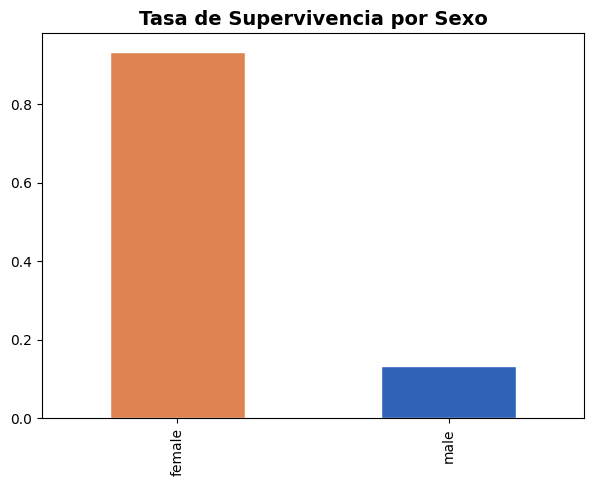

In [ ]:
supervivencia_sexo = titanic_nuevo.groupby("sexo")["sobrevivio"].mean()

plt.figure(figsize=(7, 5))
supervivencia_sexo.plot(
    kind = "bar",
    color = ["#DD8452", "#3062B8"],
    edgecolor = "white",
    width = 0.5
)

plt.title("Tasa de Supervivencia por Sexo", fontsize=14, fontweight="bold")
plt.xlabel("")

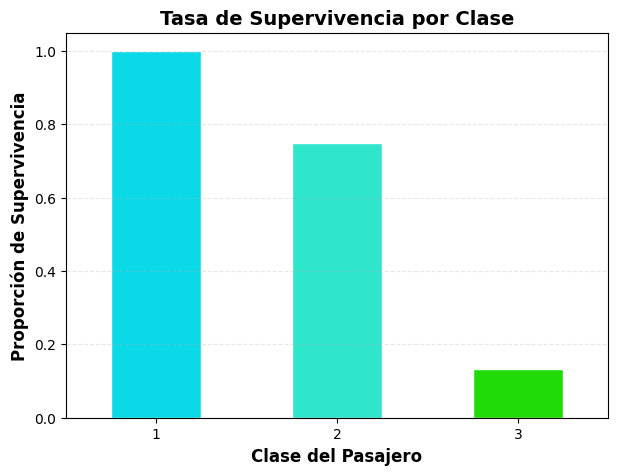

In [54]:
# 1. Agrupa y calcula la media (tasa de supervivencia)
supervivencia_sexo = titanic_nuevo.groupby("clase")["sobrevivio"].mean()

# 2. Configura el lienzo
plt.figure(figsize=(7, 5))

# 3. Dibuja las barras con tus colores neón
supervivencia_sexo.plot(
    kind = "bar",
    color = ["#0AD9E7", "#16E4C8E4", "#20db07"],
    edgecolor = "white",
    width = 0.5
)

# 4. Título y etiquetas de los ejes
plt.title("Tasa de Supervivencia por Clase", fontsize=14, fontweight="bold")
plt.xlabel("Clase del Pasajero", fontsize=12, fontweight="bold") # Título para el eje X
plt.ylabel("Proporción de Supervivencia", fontsize=12, fontweight="bold") # Título para el eje Y

# 5. Ajustes finales de legibilidad
plt.xticks(rotation=0) # Mantiene los números de las clases horizontales
plt.grid(axis='y', linestyle='--', alpha=0.3) # Agrega líneas guía suaves al fondo
plt.show()
